# Cookie Cats: где ставить первые "ворота"

В мобильной игре Cookie Cats "ворота" — момент, где игрок должен подождать или заплатить,
чтобы пройти дальше. Разработчики гоняли A/B-тест: поставить первые ворота на 30-м уровне
(как было) или сдвинуть на 40-й. Вопрос простой — не теряем ли мы игроков, если дать им
больше времени до первой "стены"?

90 189 игроков случайно разбиты на `gate_30` / `gate_40`, для каждого есть число раундов
за неделю и флаги возврата на 1-й и 7-й день. Датасет публичный — "Mobile Games A/B Testing
— Cookie Cats" (Kaggle, автор yufengsui).

Смотрю на retention_1 и retention_7 через хи-квадрат тест плюс bootstrap-CI для разницы
долей (10 000 повторов) — так видно не только p-value, но и насколько эффект большой и
надёжный.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
df = pd.read_csv("data/cookie_cats.csv")
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## EDA

In [2]:
print("Строк:", len(df))
print(df['version'].value_counts())
print("\nПропуски:\n", df.isna().sum())
df['sum_gamerounds'].describe()

Строк: 90189
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Пропуски:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Удалено выбросов: 91


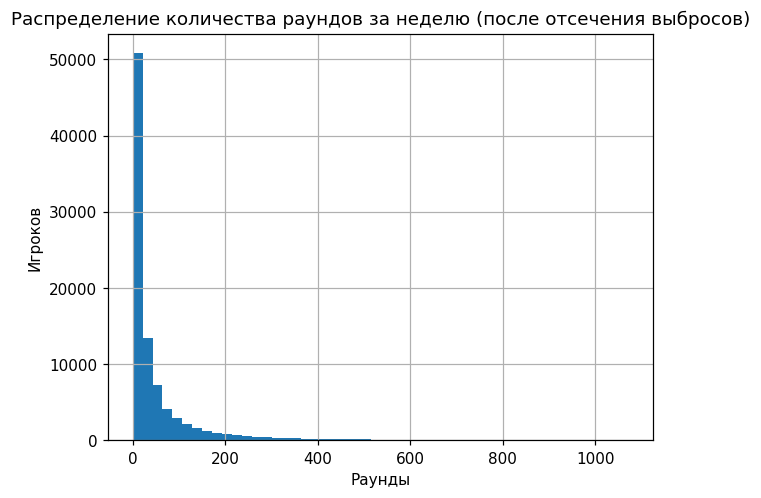

In [3]:
# Известная особенность датасета: один аномальный пользователь с 49 854 раундами.
# Отсекаем верхний 0.1% как выброс, чтобы он не искажал распределение.
df_clean = df[df['sum_gamerounds'] < df['sum_gamerounds'].quantile(0.999)].copy()
print(f"Удалено выбросов: {len(df) - len(df_clean)}")
df_clean['sum_gamerounds'].hist(bins=50)
plt.title("Распределение количества раундов за неделю (после отсечения выбросов)")
plt.xlabel("Раунды")
plt.ylabel("Игроков")
plt.savefig("charts/rounds_distribution.png", bbox_inches="tight")
plt.show()

## retention_1 и retention_7

In [4]:
def test_metric(metric):
    ct = pd.crosstab(df_clean['version'], df_clean[metric])
    rates = df_clean.groupby('version')[metric].mean()
    chi2, p, dof, exp = stats.chi2_contingency(ct)

    rng = np.random.default_rng(42)
    g30 = df_clean[df_clean.version == 'gate_30'][metric].values
    g40 = df_clean[df_clean.version == 'gate_40'][metric].values
    boot_diffs = np.array([
        rng.choice(g30, size=len(g30), replace=True).mean() -
        rng.choice(g40, size=len(g40), replace=True).mean()
        for _ in range(10000)
    ])
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

    print(f"--- {metric} ---")
    print(f"gate_30: {rates['gate_30']:.4%}   gate_40: {rates['gate_40']:.4%}")
    print(f"Разница (gate_30 - gate_40): {rates['gate_30']-rates['gate_40']:.4%}")
    print(f"Chi-square p-value: {p:.4f}")
    print(f"Bootstrap 95% CI разницы: [{ci_low:.4%}, {ci_high:.4%}]")
    print(f"P(gate_30 > gate_40) по бутстрэпу: {(boot_diffs>0).mean():.4%}\n")
    return rates, p, (ci_low, ci_high)

r1, p1, ci1 = test_metric('retention_1')
r7, p7, ci7 = test_metric('retention_7')

--- retention_1 ---
gate_30: 44.7704%   gate_40: 44.1713%
Разница (gate_30 - gate_40): 0.5991%
Chi-square p-value: 0.0715
Bootstrap 95% CI разницы: [-0.0461%, 1.2398%]
P(gate_30 > gate_40) по бутстрэпу: 96.5700%



--- retention_7 ---
gate_30: 18.9458%   gate_40: 18.1144%
Разница (gate_30 - gate_40): 0.8314%
Chi-square p-value: 0.0014
Bootstrap 95% CI разницы: [0.3154%, 1.3428%]
P(gate_30 > gate_40) по бутстрэпу: 99.9300%



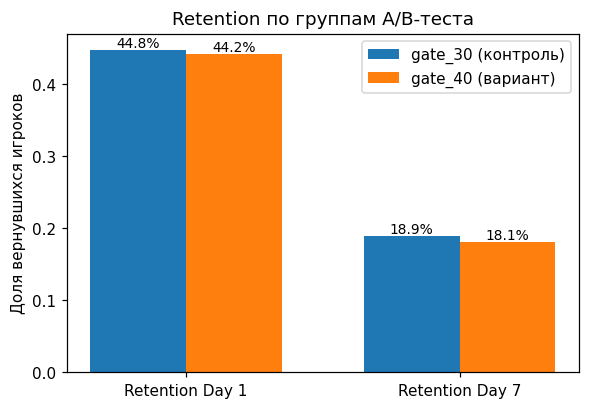

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
metrics = ['retention_1', 'retention_7']
x = np.arange(len(metrics))
width = 0.35
g30_vals = [r1['gate_30'], r7['gate_30']]
g40_vals = [r1['gate_40'], r7['gate_40']]
ax.bar(x - width/2, g30_vals, width, label='gate_30 (контроль)')
ax.bar(x + width/2, g40_vals, width, label='gate_40 (вариант)')
ax.set_xticks(x)
ax.set_xticklabels(['Retention Day 1', 'Retention Day 7'])
ax.set_ylabel('Доля вернувшихся игроков')
ax.set_title('Retention по группам A/B-теста')
ax.legend()
for i, (v30, v40) in enumerate(zip(g30_vals, g40_vals)):
    ax.text(i - width/2, v30 + 0.003, f"{v30:.1%}", ha='center', fontsize=9)
    ax.text(i + width/2, v40 + 0.003, f"{v40:.1%}", ha='center', fontsize=9)
plt.savefig("charts/retention_by_group.png", bbox_inches="tight")
plt.show()

## Вывод

- **Day 1**: gate_30 — 44.77%, gate_40 — 44.17%. Разница 0.60 п.п., p = 0.072 — не значимо
  на уровне 0.05, CI разницы пересекает ноль.
- **Day 7**: gate_30 — 18.95%, gate_40 — 18.11%. Разница 0.83 п.п., p = 0.0014 — значимо,
  95% bootstrap CI [0.32 п.п., 1.34 п.п.] ноль не пересекает. По бутстрэпу вероятность, что
  gate_30 реально лучше — 99.9%.

В первый день разницы почти не видно, но к 7-му дню более ранний гейт стабильно держит
больше игроков — и это не шум (относительное падение ~4.4% при переносе на 40-й уровень).
Двигать ворота на 40-й уровень не стоит: выигрыша в раннем удержании это не даёт, а
недельное удержание стабильно просаживает. На выборке 90К+ даже такая небольшая разница
статистически надёжна, но перед финальным решением я бы ещё смотрела на монетизацию —
здесь оценивался только retention.